## 1. Autoencoder Simple (Private Score)

In [41]:
# ============================
# 📦 Setup & Configuration
# ============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, losses
from sklearn.manifold import TSNE
import warnings
import seaborn as sns
from sklearn.metrics import roc_auc_score

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# Set random seed for reproducibility
SEED = 42
INLIERS = ['B', 'E', 'K', 'N', 'X', 'Z']  # Known inlier letters

Train: (3780, 16)
Dev: (520, 16)
Test: (1000, 16)
Entire (UCI test): (15757, 16)


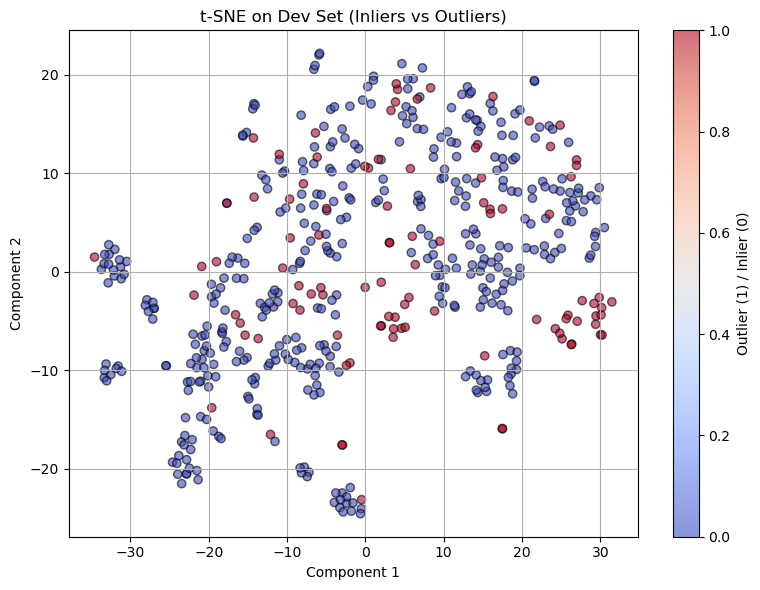

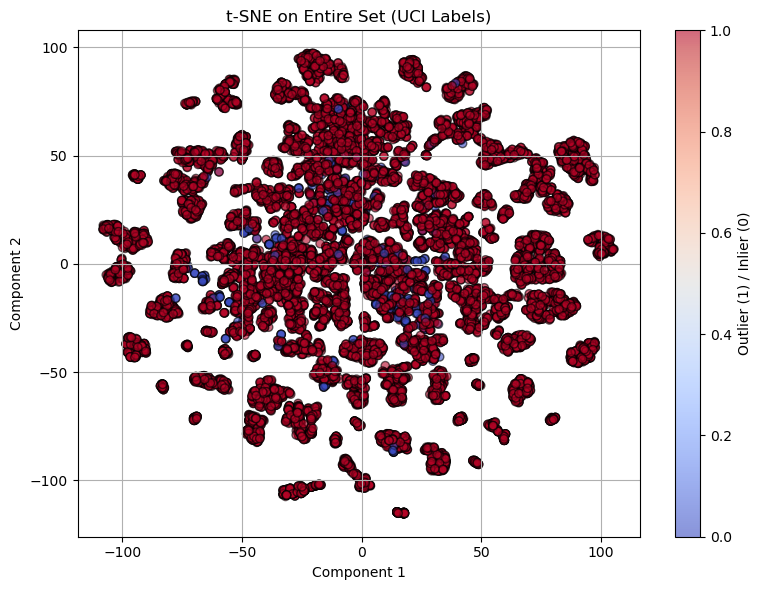

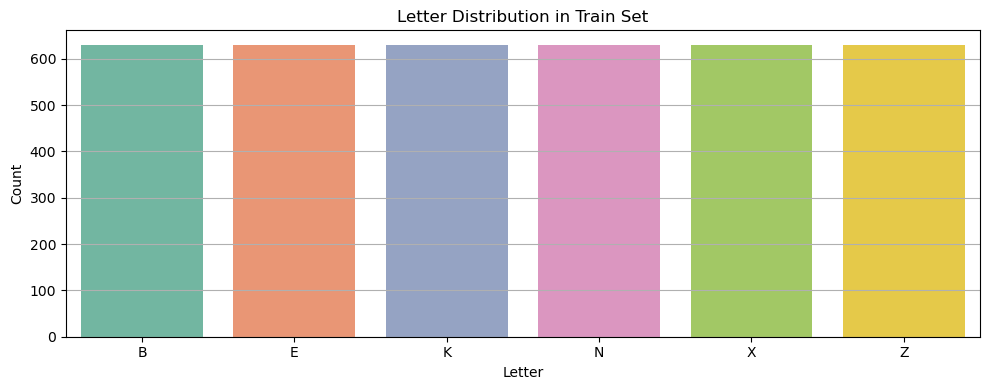

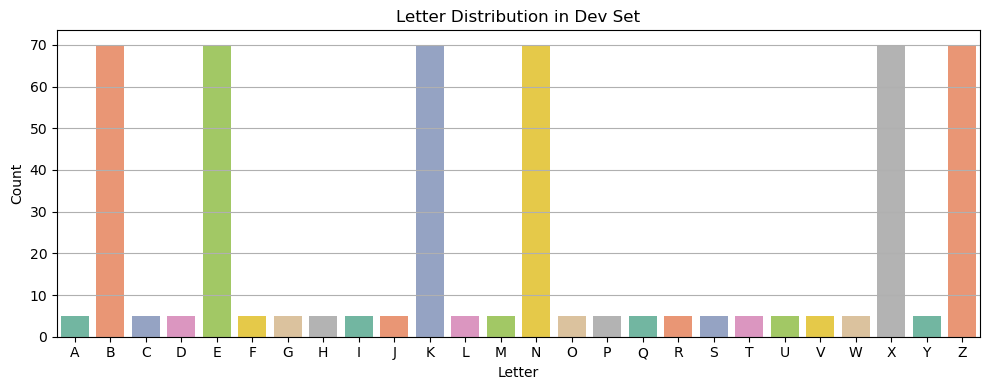

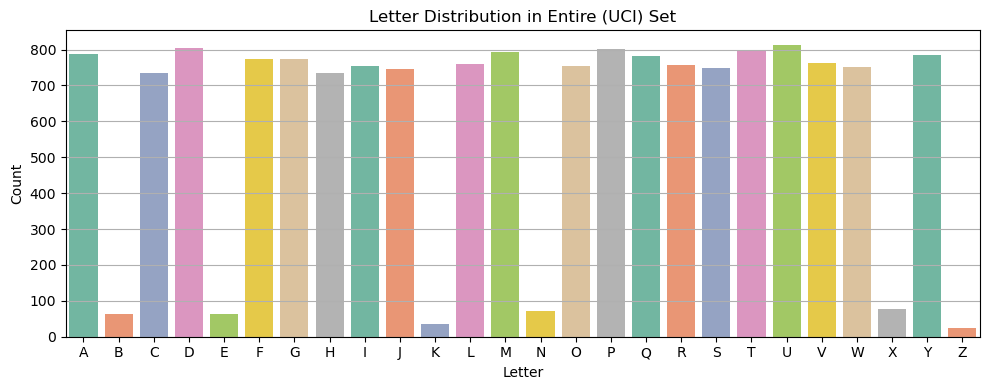

In [48]:
# ============================
# 📥 Load and Preprocess Data
# ============================
train_df = pd.read_csv("training.csv")
test_df = pd.read_csv("test_X.csv")
entire_df = pd.read_csv("entire.csv")  # Full UCI dataset

# Remove training samples from the full UCI dataset to avoid leakage
entire_df = entire_df.merge(train_df.drop_duplicates(), how='left', indicator=True)
entire_df = entire_df[entire_df['_merge'] == 'left_only'].drop(columns=['_merge']).reset_index(drop=True)

# ============================
# 🧪 Create Dev Set (10% stratified per class)
# ============================
n_classes = train_df["lettr"].nunique()
row_per_class = int((len(train_df) * 0.1) // n_classes)

dev_set = train_df.groupby('lettr').apply(lambda x: x.sample(n=min(len(x), row_per_class), random_state=SEED))
dev_set = dev_set.reset_index(level=0, drop=True)

excluded_train_df = train_df.drop(index=dev_set.index).reset_index(drop=True)

# ============================
# 🚨 Label Outliers in dev & entire sets
# ============================
entire_df["is_outlier"] = ~entire_df["lettr"].isin(INLIERS)

# Sample outliers for dev set (augment ~50 rows total)
outlier_rows = entire_df[~entire_df["lettr"].isin(INLIERS)]
n_outlier_classes = entire_df["lettr"].nunique() - train_df["lettr"].nunique()
row_per_class_entire = int(100 // n_outlier_classes)

outlier_part = outlier_rows.groupby('lettr').apply(
    lambda x: x.sample(n=min(len(x), row_per_class_entire), random_state=SEED)
).reset_index(drop=True)

# Combine original dev with outliers
dev_set = pd.concat([dev_set, outlier_part], ignore_index=True)
dev_set["is_outlier"] = ~dev_set["lettr"].isin(INLIERS)

# Extract ground truth labels for evaluation
y_dev_true = dev_set["is_outlier"].astype(int).values
y_true_entire = entire_df["is_outlier"].astype(int).values

# ============================
# 🧾 Feature Separation
# ============================
X_train_full = excluded_train_df.drop(columns='lettr')
X_dev = dev_set.drop(columns=['lettr', 'is_outlier'])
X_test = test_df.copy()
X_entire = entire_df.drop(columns=['lettr', 'is_outlier'])

# ============================
# ⚙️ Feature Scaling
# ============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_dev_scaled = scaler.transform(X_dev)
X_test_scaled = scaler.transform(X_test)
X_entire_scaled = scaler.transform(X_entire)

# ============================
# ✅ Sanity Check
# ============================
print("Train:", X_train_scaled.shape)
print("Dev:", X_dev_scaled.shape)
print("Test:", X_test_scaled.shape)
print("Entire (UCI test):", X_entire_scaled.shape)

# ============================
# 📊 t-SNE Visualization Function
# ============================
def visualize_tsne(X_scaled, labels, title="t-SNE Visualization", cmap='coolwarm', perplexity=30, figsize=(8, 6), seed=42):
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=seed)
    X_embedded = tsne.fit_transform(X_scaled)
    
    plt.figure(figsize=figsize)
    scatter = plt.scatter(
        X_embedded[:, 0], X_embedded[:, 1],
        c=labels, cmap=cmap, alpha=0.6, edgecolors='k'
    )
    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    if labels is not None:
        plt.colorbar(label="Outlier (1) / Inlier (0)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ============================
# 📈 Plot Class Distributions
# ============================
def plot_letter_distribution(df, title, label_column='lettr', figsize=(10, 4), palette='Set2'):
    letter_counts = df[label_column].value_counts().sort_index()
    plt.figure(figsize=figsize)
    sns.barplot(x=letter_counts.index, y=letter_counts.values, palette=palette)
    plt.title(title)
    plt.xlabel("Letter")
    plt.ylabel("Count")
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()
    
visualize_tsne(X_dev_scaled, y_dev_true, title="t-SNE on Dev Set (Inliers vs Outliers)")
visualize_tsne(X_entire_scaled, y_true_entire, title="t-SNE on Entire Set (UCI Labels)")

plot_letter_distribution(excluded_train_df, "Letter Distribution in Train Set")
plot_letter_distribution(dev_set, "Letter Distribution in Dev Set")
plot_letter_distribution(entire_df, "Letter Distribution in Entire (UCI) Set")



🔁 Training model 1/4 with seed 42

🔁 Training model 2/4 with seed 52

🔁 Training model 3/4 with seed 62

🔁 Training model 4/4 with seed 72


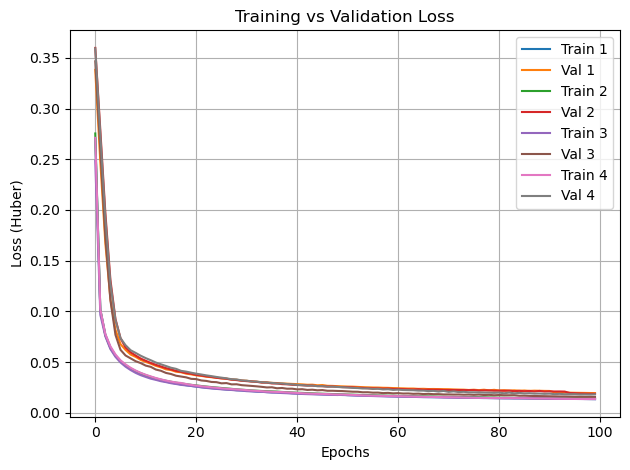


📉 Average minimum validation loss per model: 0.017910
🧪 Mean Test Reconstruction MSE: 0.053458
🧪 AUC on Dev Set: 0.9400
📦 AUC on Entire UCI Set: 0.9495

✅ solution_1_submission_1_auc_.csv saved successfully!


In [45]:
# ============================
# 🧠 Train/Validation Split
# ============================
X_train = X_train_scaled

# ============================
# 🛠️ Build Autoencoder Model
# ============================
def build_autoencoder(input_dim):
    model = models.Sequential([
        layers.Dense(128, input_shape=(input_dim,)),
        layers.LeakyReLU(alpha=0.1),
        layers.BatchNormalization(),

        layers.Dense(64),
        layers.LeakyReLU(alpha=0.1),
        layers.BatchNormalization(),

        layers.Dense(32),
        layers.LeakyReLU(alpha=0.1),

        layers.Dense(64),
        layers.LeakyReLU(alpha=0.1),
        layers.BatchNormalization(),

        layers.Dense(128),
        layers.LeakyReLU(alpha=0.1),
        layers.BatchNormalization(),

        layers.Dense(input_dim, activation='linear')
    ])
    return model

# Get input dimensionality
input_dim = X_train.shape[1]

# ============================
# 🚀 Train Ensemble Autoencoders
# ============================
all_errors = []
all_errors_dev = []
all_errors_entire = []
seeds = [42, 52, 62, 72]
val_losses = []

for i, seed in enumerate(seeds):
    print(f"\n🔁 Training model {i+1}/{len(seeds)} with seed {seed}")
    
    # Set seeds for reproducibility
    tf.random.set_seed(seed)
    np.random.seed(seed)

    # Initialize and compile model
    autoencoder = build_autoencoder(input_dim)
    autoencoder.compile(optimizer='adam', loss=losses.Huber(delta=1.0))

    # Early stopping and learning rate reduction
    early_stop = callbacks.EarlyStopping(patience=8, restore_best_weights=True)
    reduce_lr = callbacks.ReduceLROnPlateau(factor=0.5, patience=4, min_lr=1e-5)

    # Train autoencoder (no validation used here)
    history = autoencoder.fit(
        X_train, X_train,
        validation_data=(X_dev_scaled, X_dev_scaled),  # ← Add this line
        epochs=100,
        batch_size=64,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )

    # Plot training loss (optional val_loss if enabled)
    plt.plot(history.history['loss'], label=f"Train {i+1}")
    plt.plot(history.history['val_loss'], label=f"Val {i+1}")
    val_losses.append(min(history.history['val_loss']))

    # Predict on test set
    X_test_pred = autoencoder.predict(X_test_scaled, verbose=0)
    mse_test = np.mean(np.square(X_test_pred - X_test_scaled), axis=1)
    all_errors.append(mse_test)

    # Predict on dev set
    X_dev_pred = autoencoder.predict(X_dev_scaled, verbose=0)
    mse_dev = np.mean(np.square(X_dev_pred - X_dev_scaled), axis=1)
    all_errors_dev.append(mse_dev)

    # Predict on entire (UCI) set
    X_entire_pred = autoencoder.predict(X_entire_scaled, verbose=0)
    mse_entire = np.mean(np.square(X_entire_pred - X_entire_scaled), axis=1)
    all_errors_entire.append(mse_entire)

# ============================
# 📉 Plot Loss Curves
# ============================
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (Huber)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================
# 📊 Evaluation Metrics
# ============================
print(f"\n📉 Average minimum validation loss per model: {np.mean(val_losses):.6f}")

# Compute average ensemble reconstruction errors
avg_error = np.mean(all_errors, axis=0)
avg_error_dev = np.mean(all_errors_dev, axis=0)
avg_error_entire = np.mean(all_errors_entire, axis=0)

print(f"🧪 Mean Test Reconstruction MSE: {np.mean(avg_error):.6f}")

# ============================
# 📏 Normalize Outlier Scores
# ============================
outlier_scores = RobustScaler().fit_transform(avg_error.reshape(-1, 1)).flatten()
dev_scores = RobustScaler().fit_transform(avg_error_dev.reshape(-1, 1)).flatten()
entire_scores = RobustScaler().fit_transform(avg_error_entire.reshape(-1, 1)).flatten()

# ============================
# 🎯 Compute AUC Scores
# ============================
auc_dev = roc_auc_score(y_dev_true, dev_scores)
auc_entire = roc_auc_score(y_true_entire, entire_scores)

print(f"🧪 AUC on Dev Set: {auc_dev:.4f}")
print(f"📦 AUC on Entire UCI Set: {auc_entire:.4f}")

# ============================
# 📤 Create Submission File
# ============================
submission = pd.DataFrame({
    'id': np.arange(len(outlier_scores)),
    'outliers': outlier_scores
})

submission_name = "solution_1_submission_1_auc_"
submission.to_csv(f'{submission_name}.csv', index=False, float_format='%.9f')
print(f"\n✅ {submission_name}.csv saved successfully!")


## 2. AE Deep Neural Network (Public Score)

In [56]:
# ============================
# 📦 Imports and Configuration
# ============================
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Is using:", device)
INLIERS = ['B', 'E', 'K', 'N', 'X', 'Z']
SEED = 42

Is using: cuda


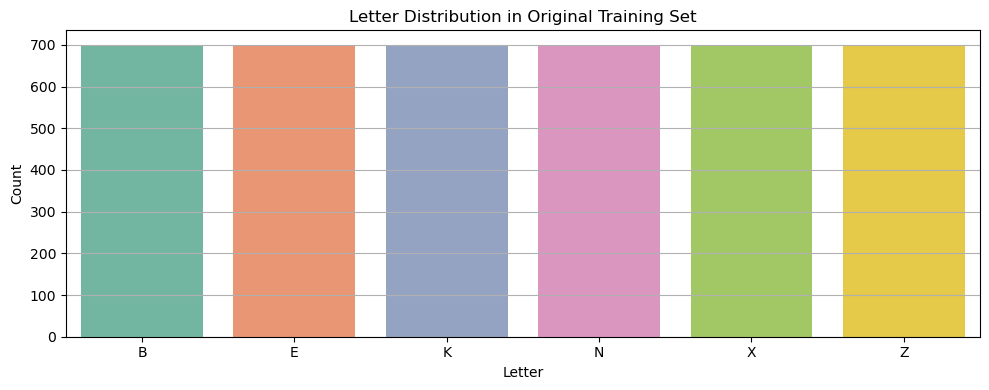

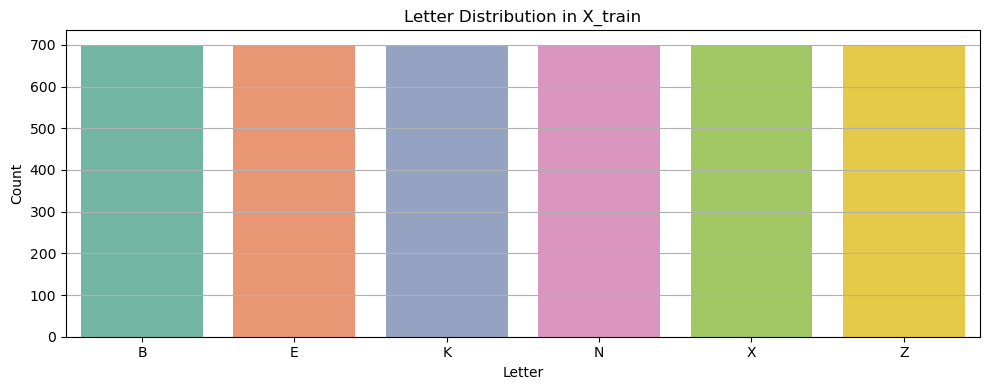

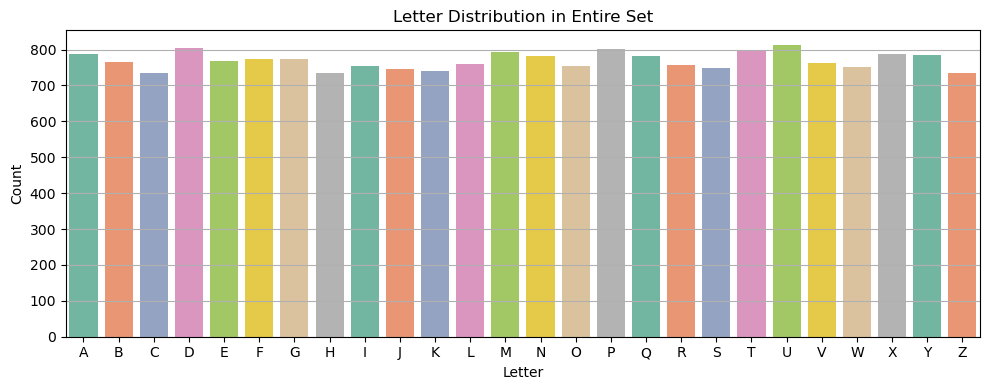

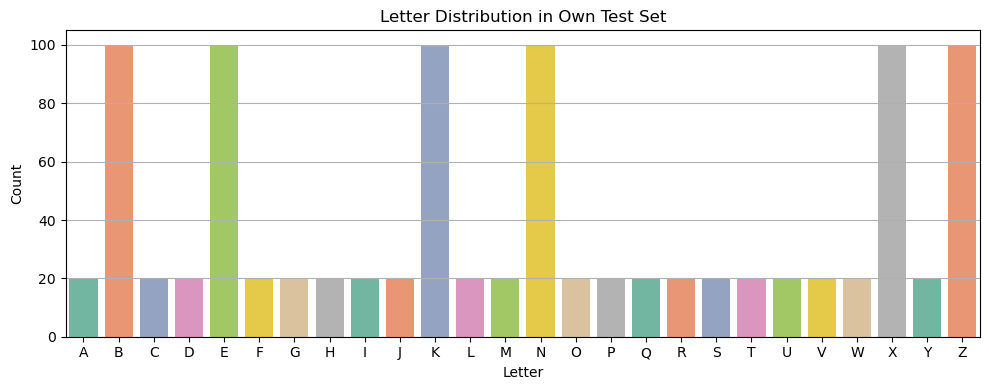

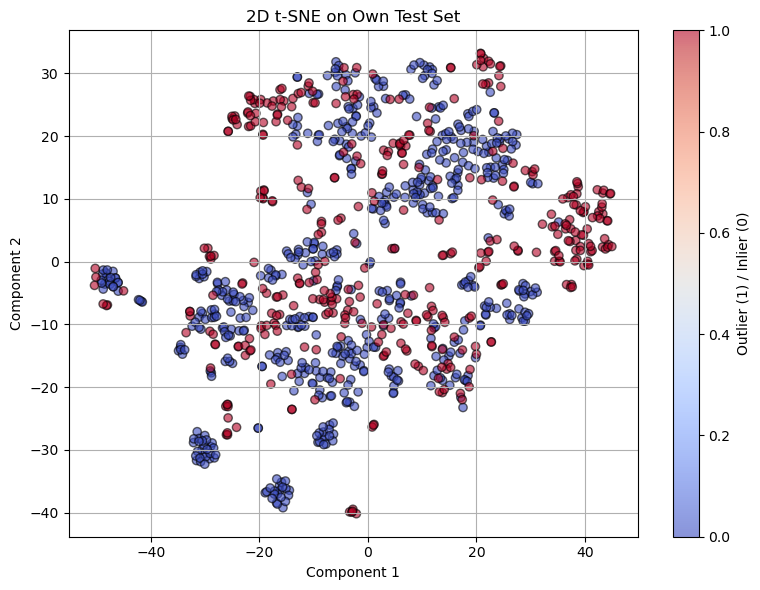

In [57]:
# ===================================
# 📥 Load Data
# ===================================
entire_df = pd.read_csv('entire.csv')
train_df = pd.read_csv('training.csv')
test_df = pd.read_csv('test_X.csv')

# ===================================
# 🔧 Preprocessing
# ===================================
X_train = train_df.drop(columns=["lettr"])
X_test = test_df.copy()

# ===================================
# 🧪 Build Own Test Set (600 Inliers, 400 Outliers)
# ===================================
inlier_nums = 600 // len(INLIERS)  # 100 samples per inlier class
outlier_nums = 400 // (len(entire_df["lettr"].unique()) - len(INLIERS))  # 20 samples per outlier class

inlier_rows = entire_df[entire_df["lettr"].isin(INLIERS)]
outlier_rows = entire_df[~entire_df["lettr"].isin(INLIERS)]

inlier_part = inlier_rows.groupby('lettr').apply(
    lambda x: x.sample(n=inlier_nums, random_state=SEED)
).reset_index(drop=True)

outlier_part = outlier_rows.groupby('lettr').apply(
    lambda x: x.sample(n=outlier_nums, random_state=SEED)
).reset_index(drop=True)

own_test_df = pd.concat([inlier_part, outlier_part], ignore_index=True).reset_index(drop=True)

X_own_test = own_test_df.drop(columns=["lettr"])
own_test_df["is_outlier"] = own_test_df["lettr"].apply(lambda x: 0 if x in INLIERS else 1)
y_own_test = own_test_df["is_outlier"]

# ===================================
# ⚙️ Feature Scaling
# ===================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_own_test_scaled = scaler.transform(X_own_test)

# ===================================
# 📈 Letter Distribution Plot Function
# ===================================
def plot_letter_distribution(df, label_column='lettr', title='Letter Distribution', palette='Set2'):
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x=label_column, order=sorted(df[label_column].unique()), palette=palette)
    plt.title(title)
    plt.xlabel("Letter")
    plt.ylabel("Count")
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()
    
# ===================================
# 📊 2D t-SNE Visualization Function
# ===================================
def visualize_tsne_2d(X_scaled, labels, title="2D t-SNE Visualization", cmap='coolwarm', perplexity=30, figsize=(8, 6), seed=42):
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=seed)
    X_embedded = tsne.fit_transform(X_scaled)

    plt.figure(figsize=figsize)
    scatter = plt.scatter(
        X_embedded[:, 0], X_embedded[:, 1],
        c=labels, cmap=cmap, alpha=0.6, edgecolors='k'
    )
    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    if labels is not None:
        plt.colorbar(label="Outlier (1) / Inlier (0)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ===================================
# 📊 Plot Class Distributions
# ===================================
plot_letter_distribution(train_df, title="Letter Distribution in Original Training Set")
plot_letter_distribution(train_df.iloc[X_train.index], title="Letter Distribution in X_train")
plot_letter_distribution(entire_df, title="Letter Distribution in Entire Set")
plot_letter_distribution(own_test_df, title="Letter Distribution in Own Test Set")

visualize_tsne_2d(X_own_test_scaled, y_own_test, title="2D t-SNE on Own Test Set")

📈 Epoch 001 | Train Loss: 0.274353 | Own Test AUC: 0.7278
📈 Epoch 002 | Train Loss: 0.182000 | Own Test AUC: 0.8597
📈 Epoch 003 | Train Loss: 0.158570 | Own Test AUC: 0.8728
📈 Epoch 004 | Train Loss: 0.144908 | Own Test AUC: 0.8994
📈 Epoch 005 | Train Loss: 0.141631 | Own Test AUC: 0.9062
📈 Epoch 006 | Train Loss: 0.124402 | Own Test AUC: 0.9194
📈 Epoch 007 | Train Loss: 0.119235 | Own Test AUC: 0.9178
📈 Epoch 008 | Train Loss: 0.113415 | Own Test AUC: 0.9314
📈 Epoch 009 | Train Loss: 0.105678 | Own Test AUC: 0.9335
📈 Epoch 010 | Train Loss: 0.104512 | Own Test AUC: 0.9363
📈 Epoch 011 | Train Loss: 0.102146 | Own Test AUC: 0.9370
📈 Epoch 012 | Train Loss: 0.098006 | Own Test AUC: 0.9417
📈 Epoch 013 | Train Loss: 0.095931 | Own Test AUC: 0.9480
📈 Epoch 014 | Train Loss: 0.097067 | Own Test AUC: 0.9446
📈 Epoch 015 | Train Loss: 0.092415 | Own Test AUC: 0.9486
📈 Epoch 016 | Train Loss: 0.090249 | Own Test AUC: 0.9480
📈 Epoch 017 | Train Loss: 0.087956 | Own Test AUC: 0.9559
📈 Epoch 018 | 

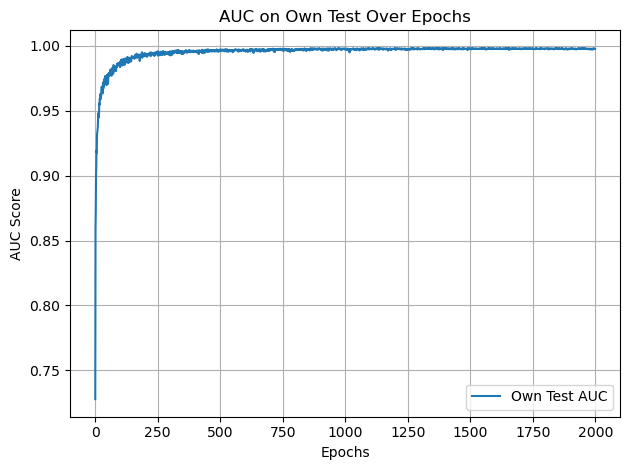

✅ Submission saved to solution_4_submission_pytorch_deepautoencoder_.csv


In [58]:
# ========= Build Deep Autoencoder =========
class DeepAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(DeepAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(512),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(256),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(128),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(64),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(32),
            nn.Linear(32, 16),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(16),
            nn.Linear(16, 8),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(8),
            nn.Linear(8,4),
            nn.LeakyReLU(0.1),
        )
        self.decoder = nn.Sequential(
            nn.Linear(4,8),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(8),
            nn.Linear(8, 16),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(16),
            nn.Linear(16, 32),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(32),
            nn.Linear(32, 64),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(64),
            nn.Linear(64, 128),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(128),
            nn.Linear(128, 256),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(256),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(512),
            nn.Linear(512, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

# ========= Prepare Data =========
def to_loader(X, batch_size=128, shuffle=False):
    if isinstance(X, pd.DataFrame):
        X = X.values  # Convert DataFrame to NumPy array
    X_tensor = torch.tensor(X, dtype=torch.float32)
    return DataLoader(TensorDataset(X_tensor), batch_size=batch_size, shuffle=shuffle)

train_loader = to_loader(X_train_scaled, shuffle=True)
test_loader = to_loader(X_test_scaled)
own_test_loader = to_loader(X_own_test_scaled)

# ========= Training Function with AUC Logging =========
def train_with_auc(
    model, train_loader, own_loader, y_own, 
    epochs=100, patience=8, lr=1e-3, device='cuda'
):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.SmoothL1Loss()

    best_auc = -1
    best_model = None
    own_aucs = []
    no_improve = 0

    for epoch in range(epochs):
        # Training loop
        model.train()
        total_loss = 0
        for batch in train_loader:
            x = batch[0].to(device)
            optimizer.zero_grad()
            recon = model(x)
            loss = criterion(recon, x)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # Evaluation on own_test
        model.eval()
        errors = []
        with torch.no_grad():
            for batch in own_loader:
                x = batch[0].to(device)
                recon = model(x)
                mse = F.mse_loss(recon, x, reduction='none').mean(dim=1)
                errors.extend(mse.cpu().numpy())

        scaled_errors = RobustScaler().fit_transform(np.array(errors).reshape(-1, 1)).flatten()
        own_auc = roc_auc_score(y_own, scaled_errors)
        own_aucs.append(own_auc)

        print(f"📈 Epoch {epoch+1:03d} | Train Loss: {total_loss/len(train_loader):.6f} | Own Test AUC: {own_auc:.4f}")

        if own_auc > best_auc:
            best_auc = own_auc
            best_model = model.state_dict()

    model.load_state_dict(best_model)
    return model, own_aucs


# ========= Run Training =========
input_dim = X_train_scaled.shape[1]
model = DeepAutoencoder(input_dim)
model, own_aucs = train_with_auc(
    model,
    train_loader,
    own_test_loader,
    y_own_test,
    epochs=2000,
    patience=10,
    lr=1e-3,
    device=device
)

# ========= Plot AUC Curves =========
plt.plot(own_aucs, label='Own Test AUC')
plt.xlabel("Epochs")
plt.ylabel("AUC Score")
plt.title("AUC on Own Test Over Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ========= Predict on Test Set =========
model.eval()
test_errors = []

with torch.no_grad():
    for batch in test_loader:
        x = batch[0].to(device)
        recon = model(x)
        mse = F.mse_loss(recon, x, reduction='none').mean(dim=1)
        test_errors.extend(mse.cpu().numpy())

# ========= Normalize Test Scores =========
test_errors = np.array(test_errors)
# normalized_scores = RobustScaler().fit_transform(test_errors.reshape(-1, 1)).flatten()
normalized_scores = test_errors.reshape(-1, 1).flatten()

# ========= Create Submission =========
submission = pd.DataFrame({
    'id': np.arange(len(normalized_scores)),
    'outliers': normalized_scores
})

# ========= Save Submission =========
submission_name = "solution_4_submission_pytorch_deepautoencoder_.csv"
submission.to_csv(submission_name, index=False, float_format='%.9f')
print(f"✅ Submission saved to {submission_name}")

## 3. SVM (Private Score)

🚀 Training One-Class SVM...
🎯 Validation AUC (One-Class SVM): 0.966077
🎯 Dev AUC (One-Class SVM): 0.972905


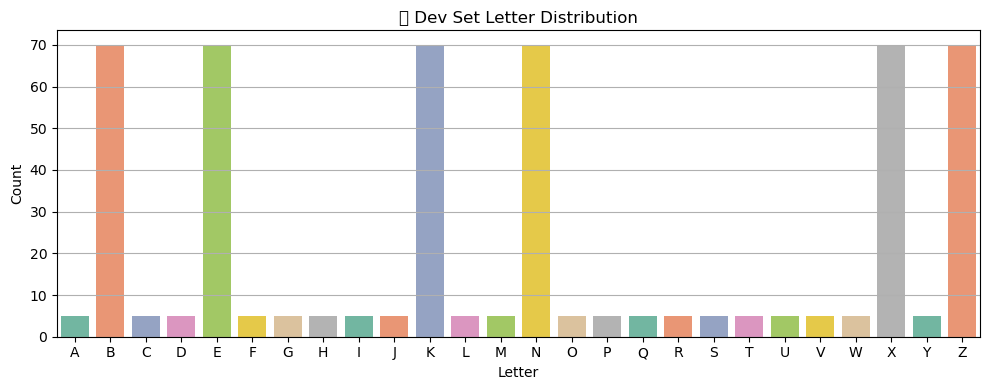

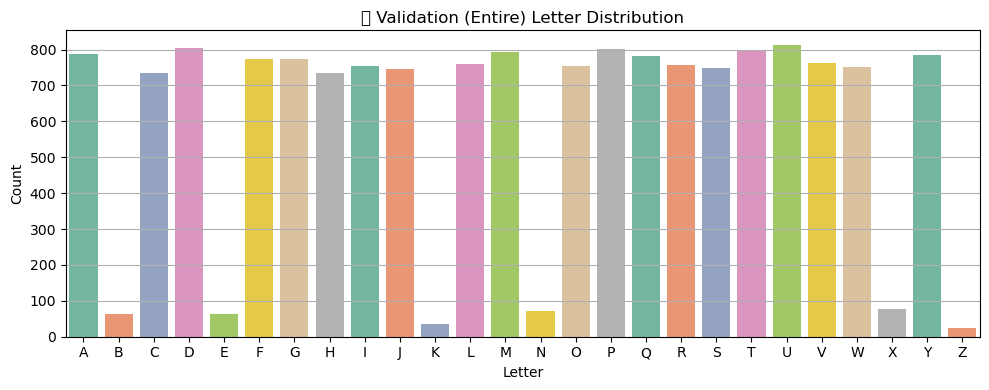

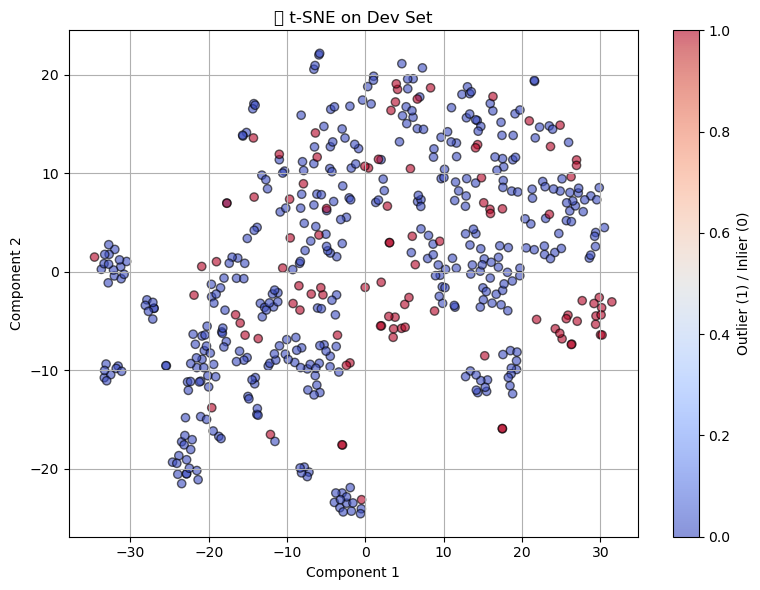

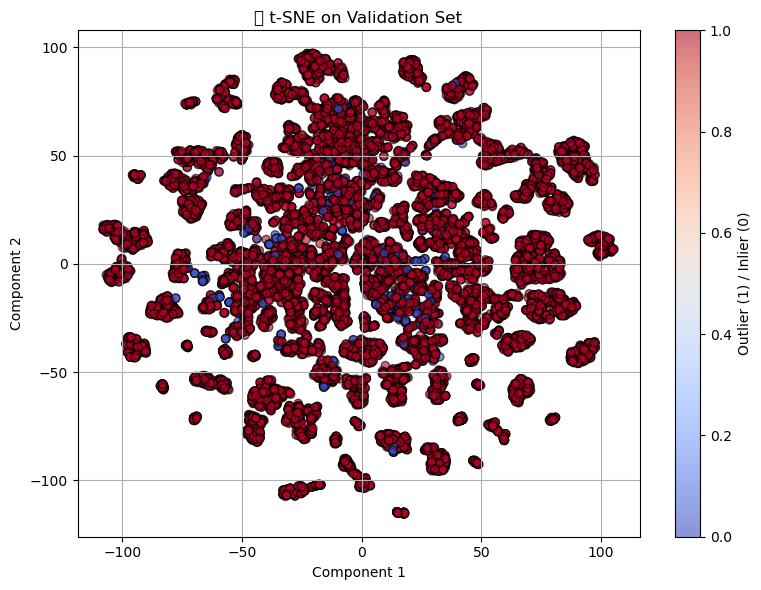

✅ Saved submission file: solution_2_submission_2_auc_.csv


In [54]:
# ================================
# 📌 One-Class SVM for Anomaly Detection
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE

# ================================
# 📊 t-SNE Visualization Function
# ================================
def visualize_tsne(X_scaled, labels, title="t-SNE Visualization", cmap='coolwarm', perplexity=30, figsize=(8, 6), seed=42):
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=seed)
    X_embedded = tsne.fit_transform(X_scaled)
    
    plt.figure(figsize=figsize)
    scatter = plt.scatter(
        X_embedded[:, 0], X_embedded[:, 1],
        c=labels, cmap=cmap, alpha=0.6, edgecolors='k'
    )
    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    if labels is not None:
        plt.colorbar(label="Outlier (1) / Inlier (0)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ================================
# 📈 Plot Class Distributions
# ================================
def plot_letter_distribution(df, title, label_column='lettr', figsize=(10, 4), palette='Set2'):
    letter_counts = df[label_column].value_counts().sort_index()
    plt.figure(figsize=figsize)
    sns.barplot(x=letter_counts.index, y=letter_counts.values, palette=palette)
    plt.title(title)
    plt.xlabel("Letter")
    plt.ylabel("Count")
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

# ================================
# STEP 1: Load and Prepare Data
# ================================

INLIERS = ['B', 'E', 'K', 'N', 'X', 'Z']
SEED = 42

train_df = pd.read_csv('training.csv')
test_df = pd.read_csv('test_X.csv')
entire_df = pd.read_csv('entire.csv')

entire_df = entire_df.merge(train_df.drop_duplicates(), how='left', indicator=True)
entire_df = entire_df[entire_df['_merge'] == 'left_only'].drop(columns=['_merge']).reset_index(drop=True)

n_classes = len(train_df["lettr"].unique())
row_per_class = int((len(train_df) * 0.1) // n_classes)
dev_df = train_df.groupby('lettr').apply(
    lambda x: x.sample(n=min(len(x), row_per_class), random_state=SEED)
).reset_index(level=0, drop=True)

excluded_train_df = train_df.drop(index=dev_df.index).reset_index(drop=True)
dev_df = dev_df.reset_index(drop=True)

entire_df["is_outlier"] = ~entire_df["lettr"].isin(INLIERS)

outlier_rows = entire_df[~entire_df["lettr"].isin(INLIERS)]
n_classes_entire = len(entire_df["lettr"].unique()) - len(train_df["lettr"].unique())
row_per_class_entire = int(100 // n_classes_entire)
outlier_part = outlier_rows.groupby('lettr').apply(
    lambda x: x.sample(n=min(len(x), row_per_class_entire), random_state=SEED)
).reset_index(drop=True)

dev_df = pd.concat([dev_df, outlier_part], ignore_index=True)
dev_df["is_outlier"] = ~dev_df["lettr"].isin(INLIERS)

# ================================
# STEP 2: Extract Features
# ================================

X_train = excluded_train_df.drop(columns=['lettr']).values.astype(np.float64)
X_test = test_df.values.astype(np.float64)

if 'lettr' in entire_df.columns:
    X_val = entire_df.drop(columns=['lettr', 'is_outlier']).values.astype(np.float64)
    y_val = entire_df['lettr'].apply(lambda x: 0 if x in INLIERS else 1).values.astype(int)
else:
    X_val, y_val = None, None

if 'lettr' in dev_df.columns:
    X_dev = dev_df.drop(columns=['lettr', 'is_outlier']).values.astype(np.float64)
    y_dev = dev_df['lettr'].apply(lambda x: 0 if x in INLIERS else 1).values.astype(int)
else:
    X_dev, y_dev = None, None

# ================================
# STEP 3: Feature Scaling
# ================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

if X_val is not None:
    X_val_scaled = scaler.transform(X_val)
if X_dev is not None:
    X_dev_scaled = scaler.transform(X_dev)

# ================================
# STEP 4: Train One-Class SVM Model
# ================================

print("🚀 Training One-Class SVM...")
ocsvm = OneClassSVM(kernel='rbf', gamma=5, nu=0.05)
ocsvm.fit(X_train_scaled)

# ================================
# STEP 5: Predict Outlier Scores
# ================================

svm_scores_raw = -ocsvm.decision_function(X_test_scaled)
svm_scores = RobustScaler().fit_transform(svm_scores_raw.reshape(-1, 1)).flatten()

# ================================
# STEP 6: Optional Validation AUC
# ================================

if X_val is not None and y_val is not None:
    val_scores_raw = -ocsvm.decision_function(X_val_scaled)
    val_scores = RobustScaler().fit_transform(val_scores_raw.reshape(-1, 1)).flatten()
    val_auc = roc_auc_score(y_val, val_scores)
    print(f"🎯 Validation AUC (One-Class SVM): {val_auc:.6f}")

if X_dev is not None and y_dev is not None:
    dev_scores_raw = -ocsvm.decision_function(X_dev_scaled)
    dev_scores = RobustScaler().fit_transform(dev_scores_raw.reshape(-1, 1)).flatten()
    dev_auc = roc_auc_score(y_dev, dev_scores)
    print(f"🎯 Dev AUC (One-Class SVM): {dev_auc:.6f}")

# ================================
# STEP 7: Visualizations
# ================================

# ➤ Distribution of letters
plot_letter_distribution(dev_df, title="🧮 Dev Set Letter Distribution")
plot_letter_distribution(entire_df, title="🧮 Validation (Entire) Letter Distribution")

# ➤ t-SNE Projections
visualize_tsne(X_dev_scaled, y_dev, title="📌 t-SNE on Dev Set")
visualize_tsne(X_val_scaled, y_val, title="📌 t-SNE on Validation Set")

# ================================
# STEP 8: Save Kaggle Submission
# ================================

submission = pd.DataFrame({
    'id': np.arange(len(svm_scores)),
    'outliers': svm_scores
})

submission_name = "solution_2_submission_2_auc_"
submission.to_csv(f'{submission_name}.csv', index=False, float_format='%.9f')
print(f"✅ Saved submission file: {submission_name}.csv")
